# Volatility Modeling of Bitcoin Returns: GARCH Family Analysis

**Objective**: Model BTC return volatility using GARCH, GJR-GARCH, and EGARCH specifications with exogenous regressors, and identify the key drivers of Bitcoin price dynamics.

**Data**: Daily observations from 2015-01-05 to 2026-02-09 (n = 4,054), sourced via public APIs.

**Model Framework**:

| Component | Specification |
|-----------|--------------|
| Mean equation | ARX: $r_t = \mu + \mathbf{X}_t \boldsymbol{\beta} + \varepsilon_t$ |
| Volatility | EGARCH(1,1): $\ln(\sigma_t^2) = \omega + \alpha \|z_{t-1}\| + \gamma z_{t-1} + \beta \ln(\sigma_{t-1}^2)$ |
| Distribution | Normal / Student-t / Skew Student-t |

**Why EGARCH over GARCH?**
- GARCH: $\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$ (requires $\omega>0,\ \alpha,\beta \geq 0$)
- EGARCH models $\ln(\sigma_t^2)$ — no non-negativity constraints needed, and the $\gamma$ term captures the **leverage effect** (asymmetric impact of positive vs. negative shocks on volatility)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model
from pathlib import Path
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

print("Ready")

Ready


---
## Part 1: Data Loading & Exploratory Analysis

In [2]:
df = pd.read_csv("ch6_data_api.csv", index_col=0, parse_dates=True)
print(f"Shape: {df.shape}")
print(f"Range: {df.index.min().date()} -> {df.index.max().date()}")
print(f"\nColumns:")
for i, col in enumerate(df.columns):
    print(f"  {i+1:2d}. {col}")

Shape: (4054, 30)
Range: 2015-01-05 -> 2026-02-09

Columns:
   1. btc
   2. oil
   3. gold
   4. msci
   5. sp500
   6. tbill
   7. tbond
   8. vix
   9. volume
  10. hashrate
  11. addresses
  12. n_tx
  13. revenue
  14. cpi
  15. gg
  16. dln_btc
  17. dln_gold
  18. dln_oil
  19. dln_sp500
  20. dln_msci
  21. dln_hashrate
  22. dln_volume
  23. dln_addresses
  24. dln_n_tx
  25. dln_revenue
  26. d_tbond
  27. d_tbill
  28. d_vix
  29. d_gg
  30. dln_cpi


In [3]:
# BTC log returns (dependent variable)
# Scale by 100 to avoid convergence warnings (arch library recommendation)
btc_ret = df["dln_btc"] * 100
btc_ret.name = "btc_ret"

print(btc_ret.describe())
print(f"\nSkewness: {btc_ret.skew():.4f}")
print(f"Kurtosis: {btc_ret.kurtosis():.4f}  (excess, normal=0)")

count    4054.000000
mean        0.137674
std         3.544306
min       -46.473018
25%        -1.222824
50%         0.121467
75%         1.590114
max        22.511895
Name: btc_ret, dtype: float64

Skewness: -0.7380
Kurtosis: 11.9874  (excess, normal=0)


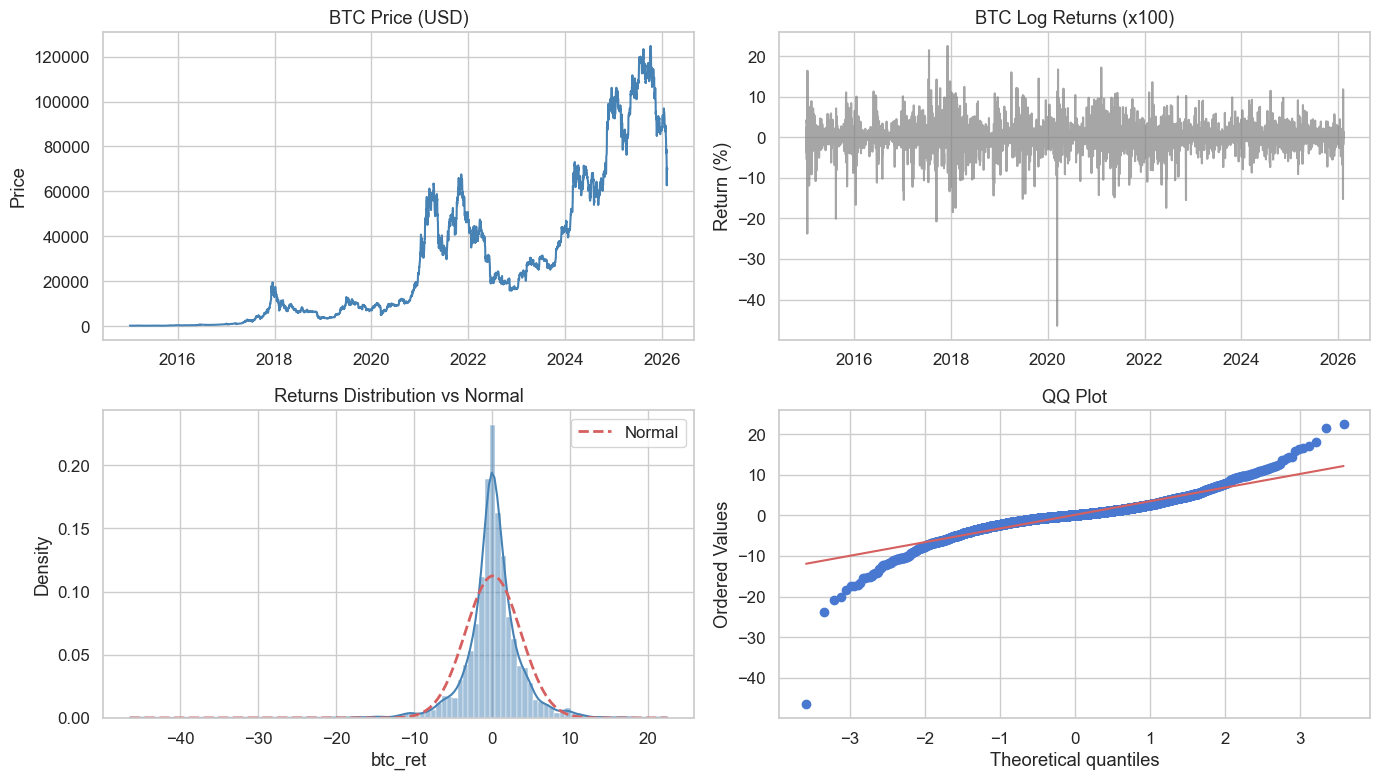

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Top-left: BTC price level
axes[0, 0].plot(df.index, df["btc"], color="steelblue")
axes[0, 0].set_title("BTC Price (USD)")
axes[0, 0].set_ylabel("Price")

# Top-right: Log returns time series — volatility clustering is visible
axes[0, 1].plot(btc_ret.index, btc_ret, color="gray", alpha=0.7)
axes[0, 1].set_title("BTC Log Returns (x100)")
axes[0, 1].set_ylabel("Return (%)")

# Bottom-left: Empirical distribution vs Normal overlay
sns.histplot(btc_ret, bins=100, kde=True, stat="density", ax=axes[1, 0], color="steelblue")
x_range = np.linspace(btc_ret.min(), btc_ret.max(), 200)
axes[1, 0].plot(x_range, stats.norm.pdf(x_range, btc_ret.mean(), btc_ret.std()),
                "r--", lw=2, label="Normal")
axes[1, 0].set_title("Returns Distribution vs Normal")
axes[1, 0].legend()

# Bottom-right: QQ plot — deviations from the line indicate heavy tails
stats.probplot(btc_ret, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("QQ Plot")

plt.tight_layout()
plt.show()

---
## Part 2: Baseline Models — GARCH(1,1) & GJR-GARCH(1,1)

We first estimate a standard GARCH(1,1) as a benchmark, then a GJR-GARCH(1,1) which adds an asymmetric leverage term $\gamma$ for negative shocks.

In [5]:
# Baseline: Constant Mean + GARCH(1,1) + Normal
garch = arch_model(btc_ret, mean="Constant", vol="Garch", p=1, q=1, dist="Normal")
garch_res = garch.fit(disp="off")
print(garch_res.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                btc_ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -10486.2
Distribution:                  Normal   AIC:                           20980.3
Method:            Maximum Likelihood   BIC:                           21005.6
                                        No. Observations:                 4054
Date:                Thu, Feb 12 2026   Df Residuals:                     4053
Time:                        00:37:08   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1642  4.775e-02      3.439  5.841e-04 [7.061e-0

In [6]:
# GJR-GARCH(1,1) — another asymmetric model
# Formula: σ²_t = ω + (α + γ·I_{t-1})·ε²_{t-1} + β·σ²_{t-1}
# I_{t-1} = 1 if ε_{t-1} < 0 (indicator for negative shocks)
# In arch library: vol="Garch", o=1 adds the asymmetric term

# GJR + Normal (compare with GARCH Normal baseline)
gjr_n = arch_model(btc_ret, mean="Constant", vol="Garch", p=1, o=1, q=1, dist="Normal")
gjr_n_res = gjr_n.fit(disp="off")

# GJR + Student-t (fair comparison with EGARCH t)
gjr_t = arch_model(btc_ret, mean="Constant", vol="Garch", p=1, o=1, q=1, dist="t")
gjr_t_res = gjr_t.fit(disp="off")

print("=== GJR-GARCH(1,1) + Normal ===")
print(f"AIC: {gjr_n_res.aic:.2f}  |  BIC: {gjr_n_res.bic:.2f}")
print(f"gamma (asymmetry): {gjr_n_res.params.get('gamma[1]', 'N/A'):.4f}, "
      f"p={gjr_n_res.pvalues.get('gamma[1]', 'N/A'):.4f}")

print(f"\n=== GJR-GARCH(1,1) + Student-t ===")
print(f"AIC: {gjr_t_res.aic:.2f}  |  BIC: {gjr_t_res.bic:.2f}")
print(f"gamma (asymmetry): {gjr_t_res.params.get('gamma[1]', 'N/A'):.4f}, "
      f"p={gjr_t_res.pvalues.get('gamma[1]', 'N/A'):.4f}")
print(f"nu (df): {gjr_t_res.params.get('nu', 'N/A'):.4f}")

=== GJR-GARCH(1,1) + Normal ===
AIC: 20969.00  |  BIC: 21000.54
gamma (asymmetry): 0.0531, p=0.2715

=== GJR-GARCH(1,1) + Student-t ===
AIC: 19952.75  |  BIC: 19990.59
gamma (asymmetry): -0.0233, p=0.2172
nu (df): 3.1678


---
## Part 3: EGARCH(1,1) — Basic

EGARCH models the log of conditional variance, which:
- Removes the need for non-negativity parameter constraints
- Captures asymmetric effects via the $\gamma$ (leverage) term

$$\ln(\sigma_t^2) = \omega + \alpha |z_{t-1}| + \gamma z_{t-1} + \beta \ln(\sigma_{t-1}^2)$$

- $\alpha > 0$: volatility response to shock magnitude
- $\gamma < 0$: leverage effect (negative shocks increase volatility more)
- $\beta \approx 1$: high volatility persistence

In [7]:
# EGARCH(1,1) with Normal distribution
egarch = arch_model(btc_ret, mean="Constant", vol="EGARCH", p=1, o=1, q=1, dist="Normal")
egarch_res = egarch.fit(disp="off")
print(egarch_res.summary())

                     Constant Mean - EGARCH Model Results                     
Dep. Variable:                btc_ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -10474.8
Distribution:                  Normal   AIC:                           20959.7
Method:            Maximum Likelihood   BIC:                           20991.2
                                        No. Observations:                 4054
Date:                Thu, Feb 12 2026   Df Residuals:                     4053
Time:                        00:37:09   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1272  4.471e-02      2.846  4.426e-03 [3.962e-0

In [8]:
# Compare GARCH vs EGARCH
comparison = pd.DataFrame({
    "GARCH(1,1)": {
        "Log-Likelihood": garch_res.loglikelihood,
        "AIC": garch_res.aic,
        "BIC": garch_res.bic,
        "Persistence": garch_res.params.get("alpha[1]", 0) + garch_res.params.get("beta[1]", 0),
    },
    "EGARCH(1,1)": {
        "Log-Likelihood": egarch_res.loglikelihood,
        "AIC": egarch_res.aic,
        "BIC": egarch_res.bic,
        "Persistence": egarch_res.params.get("beta[1]", 0),
    },
})
print(comparison.to_string())
print(f"\nLeverage (gamma): {egarch_res.params.get('gamma[1]', 'N/A'):.4f}")
print("  gamma < 0 => negative shocks increase volatility more (leverage effect)")

                  GARCH(1,1)   EGARCH(1,1)
Log-Likelihood -10486.165711 -10474.847671
AIC             20980.331421  20959.695342
BIC             21005.561258  20991.232639
Persistence         0.970610      0.936737

Leverage (gamma): -0.0412
  gamma < 0 => negative shocks increase volatility more (leverage effect)


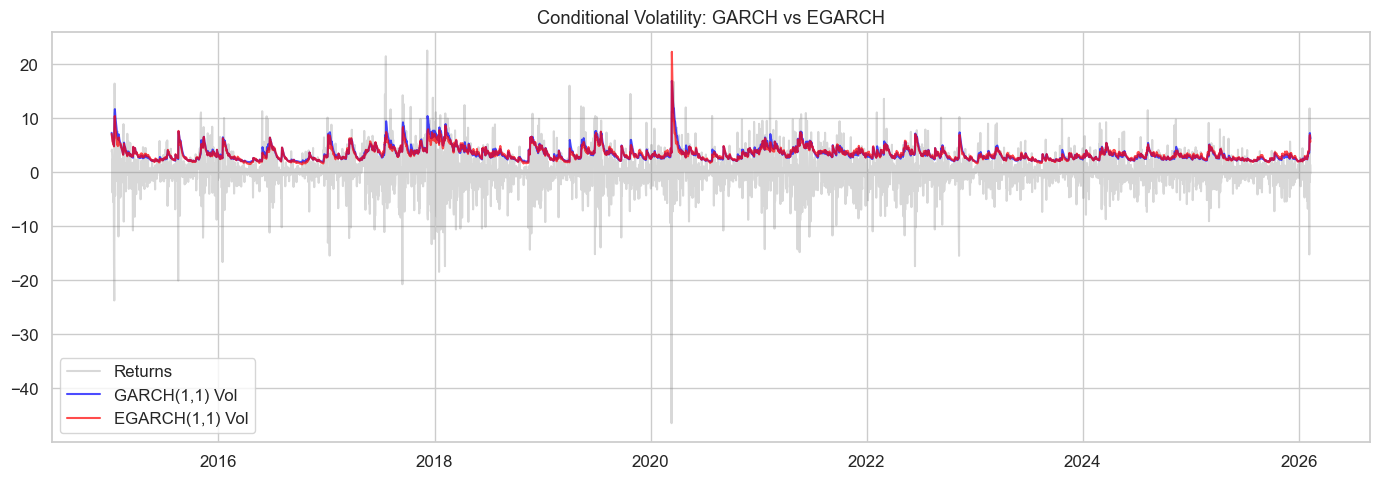

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(btc_ret.index, btc_ret, alpha=0.3, color="gray", label="Returns")
ax.plot(garch_res.conditional_volatility, color="blue", alpha=0.7, label="GARCH(1,1) Vol")
ax.plot(egarch_res.conditional_volatility, color="red", alpha=0.7, label="EGARCH(1,1) Vol")
ax.set_title("Conditional Volatility: GARCH vs EGARCH")
ax.legend()
plt.tight_layout()
plt.show()

---
## Part 4: Error Distribution Comparison

BTC returns exhibit **heavy tails** (excess kurtosis = 11.99) and **negative skewness** (-0.74). We compare three distributional assumptions for the standardized residuals:

| Distribution | Captures | Extra params |
|-------------|----------|-------------|
| Normal | Baseline | 0 |
| Student-t | Heavy tails | $\nu$ (degrees of freedom) |
| Skew Student-t | Heavy tails + asymmetry | $\eta$, $\lambda$ |

Selection criterion: **AIC** (lower = better, penalizes extra parameters).

In [10]:
distributions = ["Normal", "t", "skewt"]
dist_results = {}

for d in distributions:
    mod = arch_model(btc_ret, mean="Constant", vol="EGARCH", p=1, o=1, q=1, dist=d)
    res = mod.fit(disp="off")
    dist_results[d] = res
    print(f"\n{'='*60}")
    print(f"Distribution: {d}")
    print(f"Log-Likelihood: {res.loglikelihood:.2f}")
    print(f"AIC: {res.aic:.2f}  |  BIC: {res.bic:.2f}")
    print(f"Params: {dict(res.params.round(4))}")


Distribution: Normal
Log-Likelihood: -10474.85
AIC: 20959.70  |  BIC: 20991.23
Params: {'mu': np.float64(0.1272), 'omega': np.float64(0.1795), 'alpha[1]': np.float64(0.2546), 'gamma[1]': np.float64(-0.0412), 'beta[1]': np.float64(0.9367)}

Distribution: t
Log-Likelihood: -9945.63
AIC: 19903.25  |  BIC: 19941.10
Params: {'mu': np.float64(0.1192), 'omega': np.float64(0.0876), 'alpha[1]': np.float64(0.2492), 'gamma[1]': np.float64(0.0222), 'beta[1]': np.float64(0.9868), 'nu': np.float64(2.7247)}



Distribution: skewt
Log-Likelihood: -9945.62
AIC: 19905.24  |  BIC: 19949.40
Params: {'mu': np.float64(0.1165), 'omega': np.float64(0.0876), 'alpha[1]': np.float64(0.2493), 'gamma[1]': np.float64(0.0221), 'beta[1]': np.float64(0.9868), 'eta': np.float64(2.7246), 'lambda': np.float64(-0.0017)}


In [11]:
# Summary table
dist_comp = pd.DataFrame({
    d: {"LL": r.loglikelihood, "AIC": r.aic, "BIC": r.bic, "# Params": len(r.params)}
    for d, r in dist_results.items()
}).T

print(dist_comp.to_string())
best_dist = dist_comp["AIC"].idxmin()
print(f"\nBest distribution by AIC: {best_dist}")

                  LL           AIC           BIC  # Params
Normal -10474.847671  20959.695342  20991.232639       5.0
t       -9945.626050  19903.252101  19941.096857       6.0
skewt   -9945.622042  19905.244084  19949.396300       7.0

Best distribution by AIC: t


---
## Part 5: EGARCH with Exogenous Variables (Mean Equation)

We augment the mean equation with exogenous regressors from three categories:

| Category | Variables |
|----------|----------|
| **Market** | gold, oil, VIX, T-bond, T-bill |
| **On-chain** | hashrate, volume, active addresses, transaction count |
| **Macro / Sentiment** | CPI, Google Trends |

**Notes**:
- Exogenous variables enter only the **mean equation**, not the variance equation (limitation of the `arch` library).
- Variables dropped due to multicollinearity: `dln_msci` (r=0.97 with SP500), `dln_sp500` (r=-0.80 with VIX), `dln_revenue` (r=0.86 with volume).

In [12]:
# Prepare exogenous variables (all scaled x100 for consistency)
# 
# Dropped due to multicollinearity (from correlation analysis):
#   dln_msci    — r=0.97 with dln_sp500 (MSCI ~60% US stocks)
#   dln_sp500   — r=-0.80 with d_vix (VIX derived from SP500 options)
#   dln_revenue — r=0.86 with dln_volume (revenue ~ price x volume)
#
# Kept: d_vix over dln_sp500 (VIX more relevant to BTC volatility)
#       dln_volume over dln_revenue (volume is more fundamental)

exog_cols = [
    # Market
    "dln_gold", "dln_oil", "d_vix", "d_tbond", "d_tbill",
    # On-chain
    "dln_hashrate", "dln_volume", "dln_addresses", "dln_n_tx",
    # Macro
    "dln_cpi",
    # Sentiment
    "d_gg",
]

available = [c for c in exog_cols if c in df.columns]
missing = [c for c in exog_cols if c not in df.columns]
if missing:
    print(f"Missing columns (skipped): {missing}")

exog = df[available] * 100

print(f"Exogenous variables ({len(available)}):")
for c in available:
    n_bad = exog[c].isna().sum() + np.isinf(exog[c]).sum()
    print(f"  - {c}" + (f"  [!] {n_bad} NaN/inf" if n_bad > 0 else ""))

exog = exog.replace([np.inf, -np.inf], np.nan).dropna()
btc_ret_clean = btc_ret.loc[exog.index]
print(f"\nUsable observations: {len(exog)}")

Exogenous variables (11):
  - dln_gold
  - dln_oil  [!] 2 NaN/inf
  - d_vix
  - d_tbond
  - d_tbill
  - dln_hashrate
  - dln_volume
  - dln_addresses
  - dln_n_tx
  - dln_cpi
  - d_gg

Usable observations: 4052


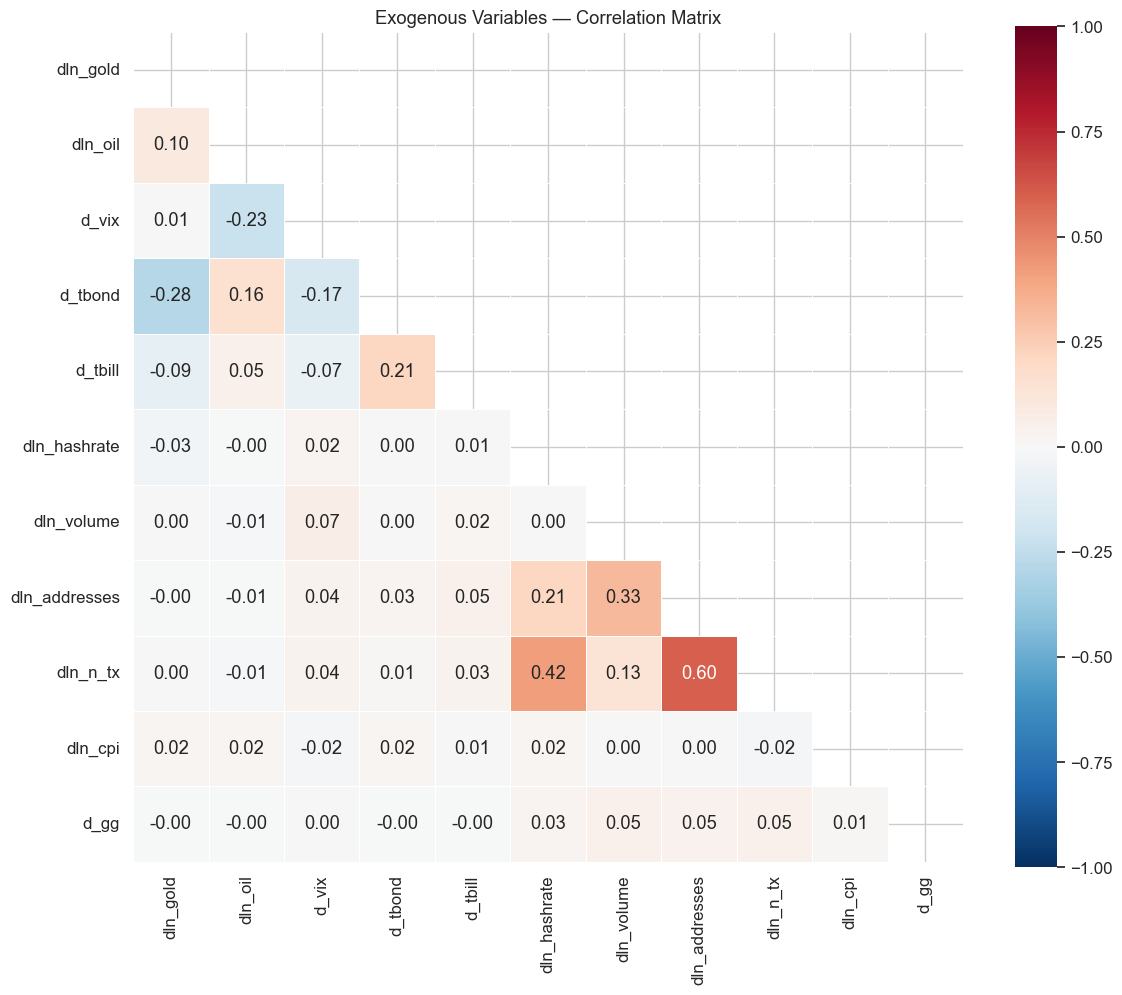

No high correlations found — multicollinearity is controlled.


In [13]:
# Correlation heatmap — check for remaining multicollinearity among regressors
fig, ax = plt.subplots(figsize=(12, 10))
corr = exog.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("Exogenous Variables — Correlation Matrix")
plt.tight_layout()
plt.show()

# Flag high correlations (|r| > 0.7)
high_corr = corr.where(mask == False).stack()
high_corr = high_corr[(high_corr.abs() > 0.7) & (high_corr.abs() < 1.0)]
if not high_corr.empty:
    print("High correlations (|r| > 0.7):")
    for (v1, v2), r in high_corr.items():
        print(f"  {v1} <-> {v2}: {r:.3f}")
else:
    print("No high correlations found — multicollinearity is controlled.")

In [14]:
# Step 1: Try full model with more iterations
egarch_x = arch_model(
    btc_ret_clean, x=exog, mean="ARX", lags=0,
    vol="EGARCH", p=1, o=1, q=1, dist=best_dist
)
egarch_x_res = egarch_x.fit(disp="off", options={"maxiter": 500})

if egarch_x_res.convergence_flag != 0:
    print(f"WARNING: Convergence flag = {egarch_x_res.convergence_flag}")
    print("Full model did not converge. Dropping insignificant variables...\n")
    
    # Keep only variables with p < 0.3 from first pass (generous threshold)
    vol_params = {"Const", "omega", "alpha[1]", "gamma[1]", "beta[1]", "nu", "eta", "lambda"}
    keep = [name for name in egarch_x_res.pvalues.index
            if name in vol_params or egarch_x_res.pvalues[name] < 0.3]
    drop_exog = [name for name in exog.columns if name not in keep]
    print(f"Dropped: {drop_exog}")
    
    exog_reduced = exog.drop(columns=drop_exog)
    egarch_x = arch_model(
        btc_ret_clean, x=exog_reduced, mean="ARX", lags=0,
        vol="EGARCH", p=1, o=1, q=1, dist=best_dist
    )
    egarch_x_res = egarch_x.fit(disp="off", options={"maxiter": 500})

print(egarch_x_res.summary())

                            AR-X - EGARCH Model Results                             
Dep. Variable:                      btc_ret   R-squared:                       0.053
Mean Model:                            AR-X   Adj. R-squared:                  0.050
Vol Model:                           EGARCH   Log-Likelihood:               -9850.85
Distribution:      Standardized Student's t   AIC:                           19735.7
Method:                  Maximum Likelihood   BIC:                           19842.9
                                              No. Observations:                 4052
Date:                      Thu, Feb 12 2026   Df Residuals:                     4040
Time:                              00:37:10   Df Model:                           12
                                    Mean Model                                    
                     coef    std err          t      P>|t|        95.0% Conf. Int.
---------------------------------------------------------------------

In [15]:
# Extract significant exogenous variables (p < 0.05)
pvals = egarch_x_res.pvalues
sig_mask = pvals < 0.05

print("Significant variables (p < 0.05):")
print("=" * 50)
for name in pvals[sig_mask].index:
    coef = egarch_x_res.params[name]
    pv = pvals[name]
    stars = "***" if pv < 0.001 else "**" if pv < 0.01 else "*"
    print(f"  {name:20s}  coef={coef:+.4f}  p={pv:.4f} {stars}")

print(f"\nNon-significant (p >= 0.05):")
for name in pvals[~sig_mask].index:
    print(f"  {name:20s}  p={pvals[name]:.4f}")

Significant variables (p < 0.05):
  Const                 coef=+0.1269  p=0.0009 ***
  dln_gold              coef=+0.2638  p=0.0000 ***
  d_vix                 coef=-0.0030  p=0.0000 ***
  d_tbill               coef=+0.0211  p=0.0000 ***
  dln_hashrate          coef=-0.0049  p=0.0091 **
  dln_volume            coef=+0.0037  p=0.0000 ***
  dln_n_tx              coef=+0.0072  p=0.0000 ***
  dln_cpi               coef=+1.0052  p=0.0000 ***
  omega                 coef=+0.0885  p=0.0000 ***
  alpha[1]              coef=+0.2562  p=0.0000 ***
  beta[1]               coef=+0.9852  p=0.0000 ***
  nu                    coef=+2.7989  p=0.0000 ***

Non-significant (p >= 0.05):
  dln_oil               p=0.5946
  d_tbond               p=0.9063
  dln_addresses         p=0.4349
  d_gg                  p=0.1551
  gamma[1]              p=0.1086


### General-to-Specific Model Selection

We follow a **general-to-specific** approach:
1. Estimate the full model with all 11 regressors
2. Identify significant variables at p < 0.05
3. Re-estimate with only significant regressors (parsimonious model)
4. Further trim variables that lose significance after re-estimation

In [16]:
# Keep only significant exogenous variables from mean equation
# Filter out model structural params — only keep exog variable names
model_params = {"Const", "mu", "omega", "alpha[1]", "gamma[1]", "beta[1]", "nu", "eta", "lambda"}
sig_exog = [name for name in pvals[sig_mask].index if name not in model_params]

if sig_exog:
    # sig_exog names might not match exog columns if model was re-fitted with reduced exog
    # Use intersection to be safe
    valid_exog = [c for c in sig_exog if c in exog.columns]
    exog_slim = exog[valid_exog]
    print(f"Significant exog variables: {valid_exog}\n")
    
    egarch_slim = arch_model(
        btc_ret_clean, x=exog_slim, mean="ARX", lags=0,
        vol="EGARCH", p=1, o=1, q=1, dist=best_dist
    )
    egarch_slim_res = egarch_slim.fit(disp="off", options={"maxiter": 500})
    print(egarch_slim_res.summary())
else:
    print("No significant exogenous variables found at p<0.05.")
    print("Using the basic EGARCH(1,1) as the final model.")
    egarch_slim_res = dist_results[best_dist]

Significant exog variables: ['dln_gold', 'd_vix', 'd_tbill', 'dln_hashrate', 'dln_volume', 'dln_n_tx', 'dln_cpi']



                            AR-X - EGARCH Model Results                             
Dep. Variable:                      btc_ret   R-squared:                       0.053
Mean Model:                            AR-X   Adj. R-squared:                  0.052
Vol Model:                           EGARCH   Log-Likelihood:               -9852.63
Distribution:      Standardized Student's t   AIC:                           19731.3
Method:                  Maximum Likelihood   BIC:                           19813.2
                                              No. Observations:                 4052
Date:                      Thu, Feb 12 2026   Df Residuals:                     4044
Time:                              00:37:10   Df Model:                            8
                                    Mean Model                                   
                    coef    std err          t      P>|t|        95.0% Conf. Int.
-----------------------------------------------------------------------

In [17]:
# Final model: 5 significant exog variables
final_exog_cols = ["dln_gold", "d_vix", "dln_volume", "dln_n_tx", "dln_cpi"]
exog_final = exog[final_exog_cols]

egarch_final = arch_model(
    btc_ret_clean, x=exog_final, mean="ARX", lags=0,
    vol="EGARCH", p=1, o=1, q=1, dist=best_dist
)
egarch_final_res = egarch_final.fit(disp="off", options={"maxiter": 500})
print(egarch_final_res.summary())

# Update best model reference for diagnostics
egarch_slim_res = egarch_final_res

                            AR-X - EGARCH Model Results                             
Dep. Variable:                      btc_ret   R-squared:                       0.053
Mean Model:                            AR-X   Adj. R-squared:                  0.052
Vol Model:                           EGARCH   Log-Likelihood:               -9855.16
Distribution:      Standardized Student's t   AIC:                           19732.3
Method:                  Maximum Likelihood   BIC:                           19801.7
                                              No. Observations:                 4052
Date:                      Thu, Feb 12 2026   Df Residuals:                     4046
Time:                              00:37:11   Df Model:                            6
                                   Mean Model                                  
                  coef    std err          t      P>|t|        95.0% Conf. Int.
---------------------------------------------------------------------------

### Final Model

After the second pass, `d_tbill` (p=0.253) and `dln_hashrate` (p=0.056) lost significance. The final parsimonious model retains **5 exogenous variables**: gold, VIX, volume, transaction count, and CPI.

---
## Part 6: Model Diagnostics

A well-specified GARCH model should produce standardized residuals $z_t = \varepsilon_t / \sigma_t$ that are approximately i.i.d. We check this with:

| Test | H0 | Good model if |
|------|-----|--------------|
| Ljung-Box (levels) | No serial correlation in $z_t$ | p > 0.05 |
| Ljung-Box (squared) | No remaining ARCH effects in $z_t^2$ | p > 0.05 |

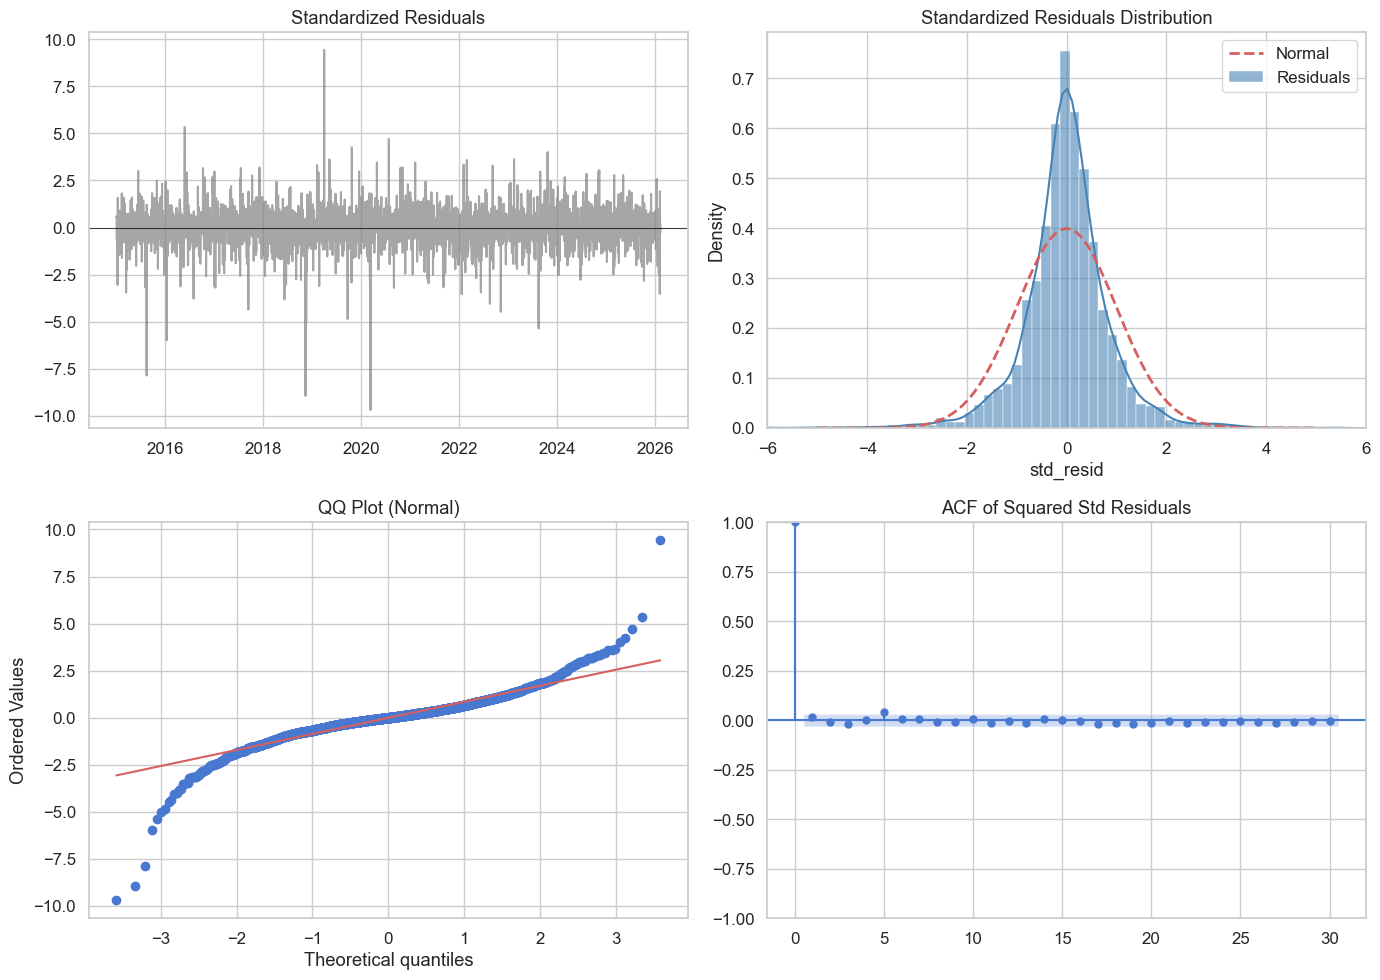

In [18]:
best_res = egarch_slim_res
std_resid = best_res.std_resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Standardized residuals over time
axes[0, 0].plot(std_resid, color="gray", alpha=0.7)
axes[0, 0].axhline(0, color="black", lw=0.5)
axes[0, 0].set_title("Standardized Residuals")

# 2. Distribution vs Normal reference
sns.histplot(std_resid, bins=100, kde=True, stat="density",
             ax=axes[0, 1], color="steelblue", alpha=0.6, label="Residuals")
x_range = np.linspace(-5, 5, 200)
axes[0, 1].plot(x_range, stats.norm.pdf(x_range), "r--", lw=2, label="Normal")
axes[0, 1].set_title("Standardized Residuals Distribution")
axes[0, 1].set_xlim(-6, 6)
axes[0, 1].legend()

# 3. QQ plot — remaining tail behavior after EGARCH filtering
stats.probplot(std_resid, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("QQ Plot (Normal)")

# 4. ACF of squared residuals — should show no significant spikes
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(std_resid**2, lags=30, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title("ACF of Squared Std Residuals")

plt.tight_layout()
plt.show()

In [19]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Ljung-Box on standardized residuals (check for serial correlation)
lb_resid = acorr_ljungbox(std_resid, lags=[10, 20, 30], return_df=True)
print("Ljung-Box Test on Standardized Residuals:")
print(lb_resid)
print("  -> p > 0.05 means no significant serial correlation (good)")

print()

# Ljung-Box on squared standardized residuals (check for remaining ARCH effects)
lb_sq = acorr_ljungbox(std_resid**2, lags=[10, 20, 30], return_df=True)
print("Ljung-Box Test on Squared Std Residuals:")
print(lb_sq)
print("  -> p > 0.05 means no remaining ARCH effects (good)")

Ljung-Box Test on Standardized Residuals:
      lb_stat  lb_pvalue
10  31.063337   0.000573
20  39.178938   0.006334
30  51.497443   0.008624
  -> p > 0.05 means no significant serial correlation (good)

Ljung-Box Test on Squared Std Residuals:
      lb_stat  lb_pvalue
10  10.634739   0.386674
20  17.808723   0.600007
30  21.133122   0.883679
  -> p > 0.05 means no remaining ARCH effects (good)


---
## Part 7: Volatility Forecast

- `forecast(horizon=1)`: analytic (exact) 1-step-ahead forecast
- `forecast(horizon=h, method="simulation")`: multi-step via Monte Carlo
- With exogenous variables, the `arch` library cannot produce multi-step forecasts (future exog values are unknown), so we use the **basic EGARCH(1,1) + Student-t** for the forecast demonstration.
- Since $\nu \approx 2.8$ (extremely heavy tails), we report **median** alongside mean to reduce outlier sensitivity.

In [20]:
# Use the basic EGARCH(1,1) + Student-t for forecasting
best_basic = dist_results[best_dist]

# --- 1-step analytic forecast ---
fc_1 = best_basic.forecast(horizon=1)
vol_1 = np.sqrt(fc_1.variance.iloc[-1].values[0])
ann_vol = vol_1 * np.sqrt(365)
print(f"1-day ahead volatility: {vol_1:.4f}%")
print(f"Annualized: {ann_vol:.2f}%")

# --- Multi-step simulation forecast ---
# nu=2.8 -> extreme heavy tails; mean is unstable, median is more robust
fc_sim = best_basic.forecast(horizon=10, method="simulation", simulations=5000)

var_paths = fc_sim.simulations.variances[-1]  # shape: (5000, 10)
vol_median = np.sqrt(np.median(var_paths, axis=0))
vol_mean = np.sqrt(fc_sim.variance.iloc[-1].values)

print(f"\n10-day forecast (daily volatility %):")
print(f"{'Day':>4s}  {'Mean':>8s}  {'Median':>8s}")
print("-" * 26)
for i in range(10):
    print(f"{i+1:4d}  {vol_mean[i]:8.4f}  {vol_median[i]:8.4f}")

1-day ahead volatility: 5.7500%
Annualized: 109.85%

10-day forecast (daily volatility %):
 Day      Mean    Median
--------------------------
   1    5.7500    5.7500
   2    5.7873    5.5898
   3    5.8191    5.5355
   4    5.8623    5.4821
   5    6.0743    5.4400
   6    6.1021    5.4030
   7    6.3581    5.3539
   8    6.3667    5.3224
   9   13.0933    5.2877
  10   12.4788    5.2666


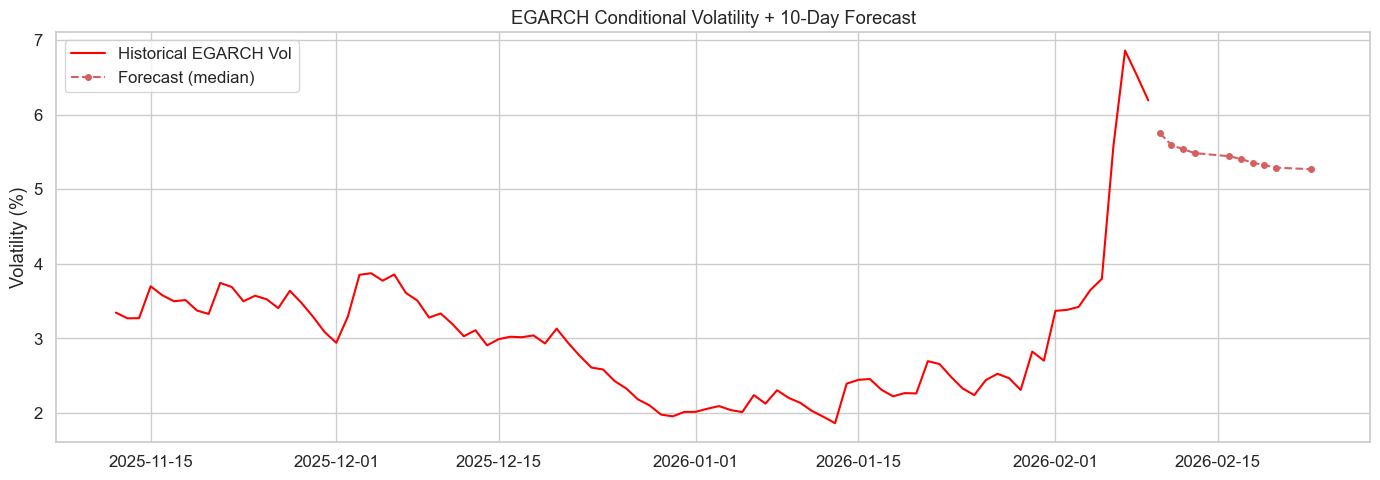

In [21]:
# Plot historical vol + forecast (median)
fig, ax = plt.subplots(figsize=(14, 5))

# Last 90 days of historical vol
hist_vol = best_basic.conditional_volatility[-90:]
ax.plot(hist_vol.index, hist_vol, color="red", label="Historical EGARCH Vol")

# Forecast (median, more robust than mean with heavy-tailed t dist)
last_date = hist_vol.index[-1]
fc_dates = pd.bdate_range(last_date, periods=11)[1:]
ax.plot(fc_dates, vol_median, "r--", marker="o", markersize=4, label="Forecast (median)")

ax.set_title("EGARCH Conditional Volatility + 10-Day Forecast")
ax.set_ylabel("Volatility (%)")
ax.legend()
plt.tight_layout()
plt.show()

---
## Part 8: Model Comparison Summary

All estimated models ranked by AIC (lower = better).

In [22]:
# Collect all models
all_models = {
    "GARCH(1,1) Normal": garch_res,
    "GJR-GARCH(1,1) Normal": gjr_n_res,
    "GJR-GARCH(1,1) t": gjr_t_res,
    "EGARCH(1,1) Normal": dist_results["Normal"],
    "EGARCH(1,1) t": dist_results["t"],
    "EGARCH(1,1) skewt": dist_results["skewt"],
    f"EGARCH+X full {best_dist}": egarch_x_res,
    f"EGARCH+X final {best_dist}": egarch_final_res,
}

summary = pd.DataFrame({
    name: {
        "Log-L": r.loglikelihood,
        "AIC": r.aic,
        "BIC": r.bic,
        "# Params": len(r.params),
    }
    for name, r in all_models.items()
}).T.sort_values("AIC")

print(summary.to_string())
print(f"\nBest model by AIC: {summary['AIC'].idxmin()}")
print(f"Best model by BIC: {summary['BIC'].idxmin()}")

                              Log-L           AIC           BIC  # Params
EGARCH+X final t       -9855.156854  19732.313707  19801.690332      11.0
EGARCH+X full t        -9850.847691  19735.695381  19842.913801      17.0
EGARCH(1,1) t          -9945.626050  19903.252101  19941.096857       6.0
EGARCH(1,1) skewt      -9945.622042  19905.244084  19949.396300       7.0
GJR-GARCH(1,1) t       -9970.374740  19952.749479  19990.594235       6.0
EGARCH(1,1) Normal    -10474.847671  20959.695342  20991.232639       5.0
GJR-GARCH(1,1) Normal -10479.500588  20969.001177  21000.538473       5.0
GARCH(1,1) Normal     -10486.165711  20980.331421  21005.561258       4.0

Best model by AIC: EGARCH+X final t
Best model by BIC: EGARCH+X final t


---
## Next Steps

- [ ] Compare results against thesis original sample (2015-2021) vs extended data (2015-2026)
- [ ] Sub-sample estimation (pre/post COVID, pre/post 2021 bull run)
- [ ] Rolling-window EGARCH to assess parameter stability over time
- [ ] News Impact Curve to visualize the (a)symmetric leverage effect